# $\textrm{SO}(3)$ Simulation

In [ ]:
import sys, os
from geomstats.geometry.special_orthogonal import _SpecialOrthogonal3Vectors

sys.path.append(os.path.join(os.path.expanduser('~'), 'Documents', 'GitHub', 'RiemannianEB', 'src'))
from utils import *

## Setting up

In [ ]:

SO3 = SpecialOrthogonal(n=3)
tau2 = 0.1
n_samples = 200
sigma2 = 0.3

def sample_G(n_samples, tau2):
    SO3 = SpecialOrthogonal(n=3)
    theta = 2 * np.pi * np.random.uniform(0, 1, size=n_samples)
    c, s = np.cos(theta), np.sin(theta)
    R = np.zeros((n_samples, 3, 3))
    R[:, 0, 0] = 1.0
    R[:, 1, 1] = c
    R[:, 1, 2] = -s
    R[:, 2, 1] = s
    R[:, 2, 2] = c
    A_tau = np.random.normal(0, np.sqrt(tau2), size=(n_samples, 3, 3))
    skew_A_tau = 0.5 * (A_tau - np.transpose(A_tau, (0, 2, 1)))
    return SO3.projection(SO3.metric.exp(skew_A_tau, R))

def XfromTheta(Theta, sigma2):
    n = Theta.shape[0]
    A_sigma = np.random.normal(0, np.sqrt(sigma2), size=(n, 3, 3))
    skew_A_sigma = 0.5 * (A_sigma - np.transpose(A_sigma, (0, 2, 1)))
    return SO3.projection(SO3.metric.exp(skew_A_sigma, Theta))

Theta = sample_G(n_samples, tau2)
Theta_angs = _SpecialOrthogonal3Vectors().tait_bryan_angles_from_matrix(Theta, extrinsic=True, zyx=True)

X = XfromTheta(Theta, sigma2)
X_angs = _SpecialOrthogonal3Vectors().tait_bryan_angles_from_matrix(X, extrinsic=True, zyx=True)


NameError: name '_SpecialOrthogonal3Vectors' is not defined

Text(0.5, 0.98, 'Riemannian Gaussian in SO$(3)$ (Tait-Bryan Euler angles)')

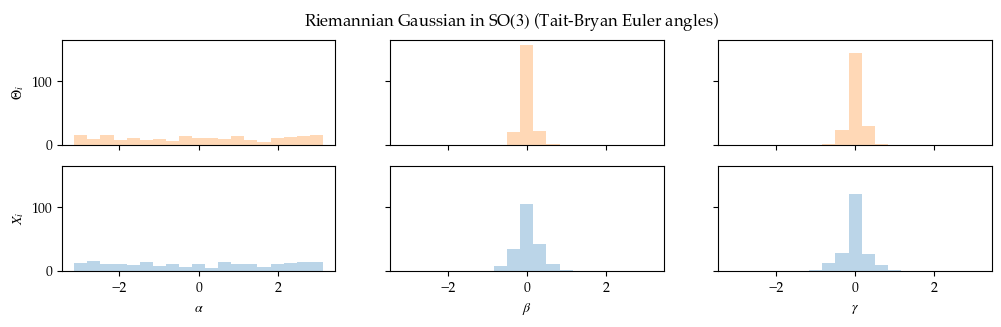

In [4]:
fig, axs = plt.subplots(2, 3, figsize=(12,3), sharex=True,sharey=True)

bins = np.linspace(-np.pi, np.pi, num=20)

for m in range(3):
    axs[0,m].hist(Theta_angs[:,m], bins=bins, color='C1', alpha=0.3)
    axs[1,m].hist(X_angs[:,m], bins=bins, color='C0', alpha=0.3)
    
axs[1,0].set_xlabel('$\\alpha$')
axs[1,1].set_xlabel('$\\beta$')
axs[1,2].set_xlabel('$\\gamma$')

axs[0,0].set_ylabel('$\\Theta_i$')
axs[1,0].set_ylabel('$X_i$')


plt.suptitle('Riemannian Gaussian in SO$(3)$ (Tait-Bryan Euler angles)')

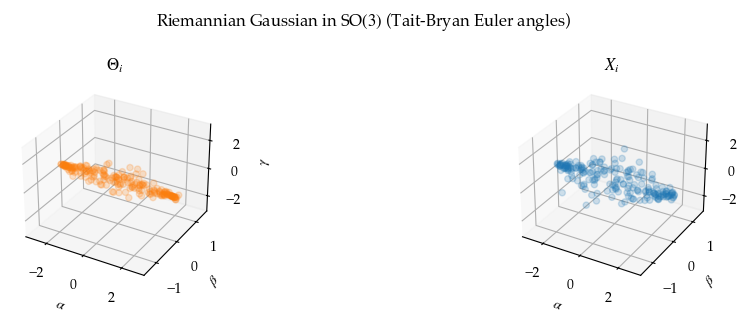

In [5]:
fig = plt.figure(figsize=(12,3))
ax = [None] * 2

ax[0] = fig.add_subplot(1, 2, 1, projection='3d')

ax[0].scatter(Theta_angs[:,0], Theta_angs[:,1], Theta_angs[:,2], color='C1', alpha=0.2)
ax[0].set_title('$\\Theta_i$')

ax[1] = fig.add_subplot(1, 2, 2, projection='3d')

ax[1].scatter(X_angs[:,0], X_angs[:,1], X_angs[:,2], color='C0', alpha=0.2)
ax[1].set_title('$X_i$')

for m in range(2):
    ax[m].set_xlabel('$\\alpha$')
    ax[m].set_ylabel('$\\beta$')
    ax[m].set_zlabel('$\\gamma$')

    ax[m].set_xlim([-np.pi, np.pi])
    ax[m].set_ylim([-np.pi/2, np.pi/2])
    ax[m].set_zlim([-np.pi, np.pi])

plt.suptitle('Riemannian Gaussian in SO$(3)$ (Tait-Bryan Euler angles)')
plt.tight_layout()

## Empirical Bayes denoising

In [6]:
M = 2
rho = 0.01
delta = denoiser('SO3', X, M, rho, sigma2, X)
delta_angs = _SpecialOrthogonal3Vectors().tait_bryan_angles_from_matrix(delta, extrinsic=True, zyx=True)

...density estimated
...denoising step completed


## Plotting

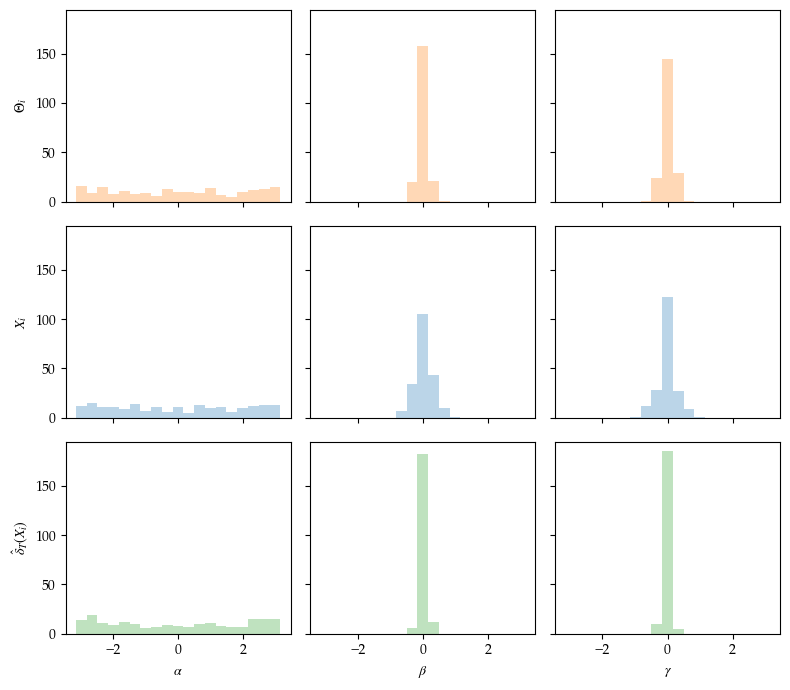

In [7]:
fig, axs = plt.subplots(3, 3, figsize=(8,7), sharex=True,sharey=True)

bins = np.linspace(-np.pi, np.pi, num=20)

for m in range(3):
    axs[0,m].hist(Theta_angs[:,m], bins=bins, color='C1', alpha=0.3)
    axs[1,m].hist(X_angs[:,m], bins=bins, color='C0', alpha=0.3)
    axs[2,m].hist(delta_angs[:,m], bins=bins, color='C2', alpha=0.3)
    
axs[2,0].set_xlabel('$\\alpha$')
axs[2,1].set_xlabel('$\\beta$')
axs[2,2].set_xlabel('$\\gamma$')

axs[0,0].set_ylabel('$\\Theta_i$')
axs[1,0].set_ylabel('$X_i$')
axs[2,0].set_ylabel('$\\hat{\delta}_T(X_i)$')

plt.tight_layout()
plt.savefig('cryoEM_marginals.pdf')

/var/folders/4l/9wthfjb520bf_3mctz_1csd00000gn/T/ipykernel_7977/3344331740.py:44: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


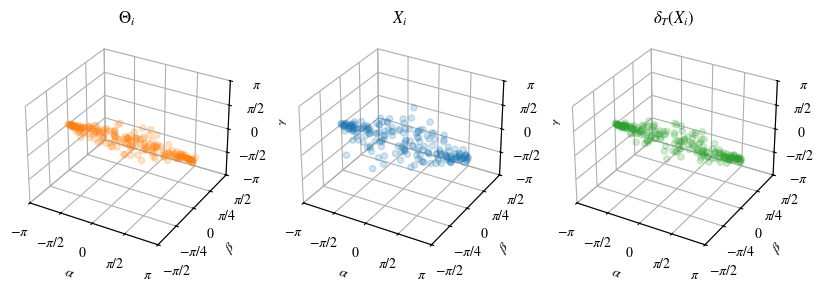

In [11]:
fig = plt.figure(figsize=(10,4))
ax = [None] * 3

ax[0] = fig.add_subplot(1, 3, 1, projection='3d')
ax[0].scatter(Theta_angs[:,0], Theta_angs[:,1], Theta_angs[:,2], color='C1', alpha=0.2)
ax[0].set_title('$\\Theta_i$')

ax[1] = fig.add_subplot(1, 3, 2, projection='3d')
ax[1].scatter(X_angs[:,0], X_angs[:,1], X_angs[:,2], color='C0', alpha=0.2)
ax[1].set_title('$X_i$')

ax[2] = fig.add_subplot(1, 3, 3, projection='3d')
ax[2].scatter(delta_angs[:,0], delta_angs[:,1], X_angs[:,2], color='C2', alpha=0.2)
ax[2].set_title('$\\delta_{T}(X_i)$')


radian_xzticks = [i * np.pi/4 for i in range(-4,5,2)]
radian_xzticklabels = ['$-\\pi$', '$-\\pi/2$', '$0$', '$\\pi/2$', '$\\pi$']

radian_yticks = [i * np.pi/8 for i in range(-4,5,2)]
radian_yticklabels = ['$-\\pi/2$', '$-\\pi/4$', '$0$', '$\\pi/4$', '$\\pi/2$']

for m in range(3):
    ax[m].set_xlabel('$\\alpha$')
    ax[m].set_ylabel('$\\beta$')
    ax[m].set_zlabel('$\\gamma$')

    ax[m].set_xlim([-np.pi, np.pi])
    ax[m].set_ylim([-np.pi/2, np.pi/2])
    ax[m].set_zlim([-np.pi, np.pi])
    
    ax[m].set_xticks(radian_xzticks)
    ax[m].set_yticks(radian_yticks)
    ax[m].set_zticks(radian_xzticks)

    ax[m].set_xticklabels(radian_xzticklabels)
    ax[m].set_yticklabels(radian_yticklabels)
    ax[m].set_zticklabels(radian_xzticklabels)
    
    ax[m].xaxis.pane.fill = False
    ax[m].yaxis.pane.fill = False
    ax[m].zaxis.pane.fill = False

plt.tight_layout()
plt.savefig('cryoEM.pdf')

In [12]:
print('MSE of delta_N:', np.mean(SO3.metric.squared_dist(X,Theta)))
print('MSE of delta_T:', np.mean(SO3.metric.squared_dist(delta,Theta)))

MSE of delta_N: 0.20836002609079338
MSE of delta_T: 0.12764830435135266


In [13]:
mse_n = np.mean(SO3.metric.squared_dist(X,Theta))
mse_t = np.mean(SO3.metric.squared_dist(delta,Theta))

In [18]:
1- mse_t/mse_n

0.3873666329081299